In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

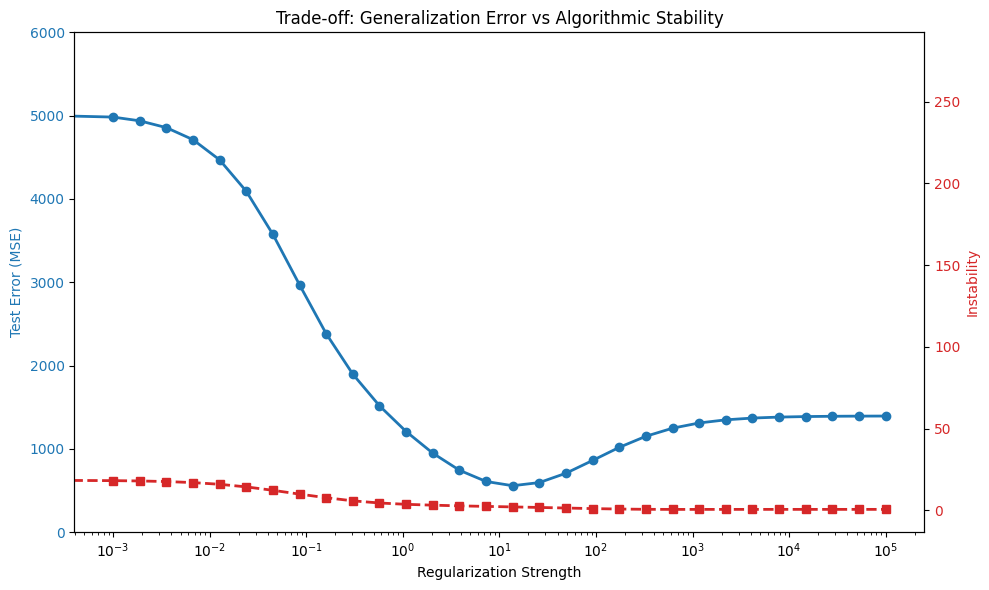

<Figure size 1600x600 with 0 Axes>

In [27]:
df_base = pd.read_csv('results/results_synthetic.csv')

fig, ax1 = plt.subplots()

ax1.set_xscale('log')
ax1.set_xlabel('Regularization Strength')

color_error = 'tab:blue'
ax1.set_ylabel('Test Error (MSE)', color=color_error)
ax1.set_ylim(0, 6000)
ax1.plot(df_base['lambda'], df_base['test_error'], marker='o', linewidth=2, color=color_error, label='Test Error')
ax1.tick_params(axis='y', labelcolor=color_error)

ax2 = ax1.twinx()
color_instab = 'tab:red'
ax2.set_ylabel('Instability', color=color_instab)
ax2.plot(df_base['lambda'], df_base['instability'], marker='s', linestyle='--', linewidth=2, color=color_instab, label='Instability')
ax2.tick_params(axis='y', labelcolor=color_instab)

plt.title('Trade-off: Generalization Error vs Algorithmic Stability')
plt.figure(figsize=(16, 6))
fig.tight_layout()
plt.show()

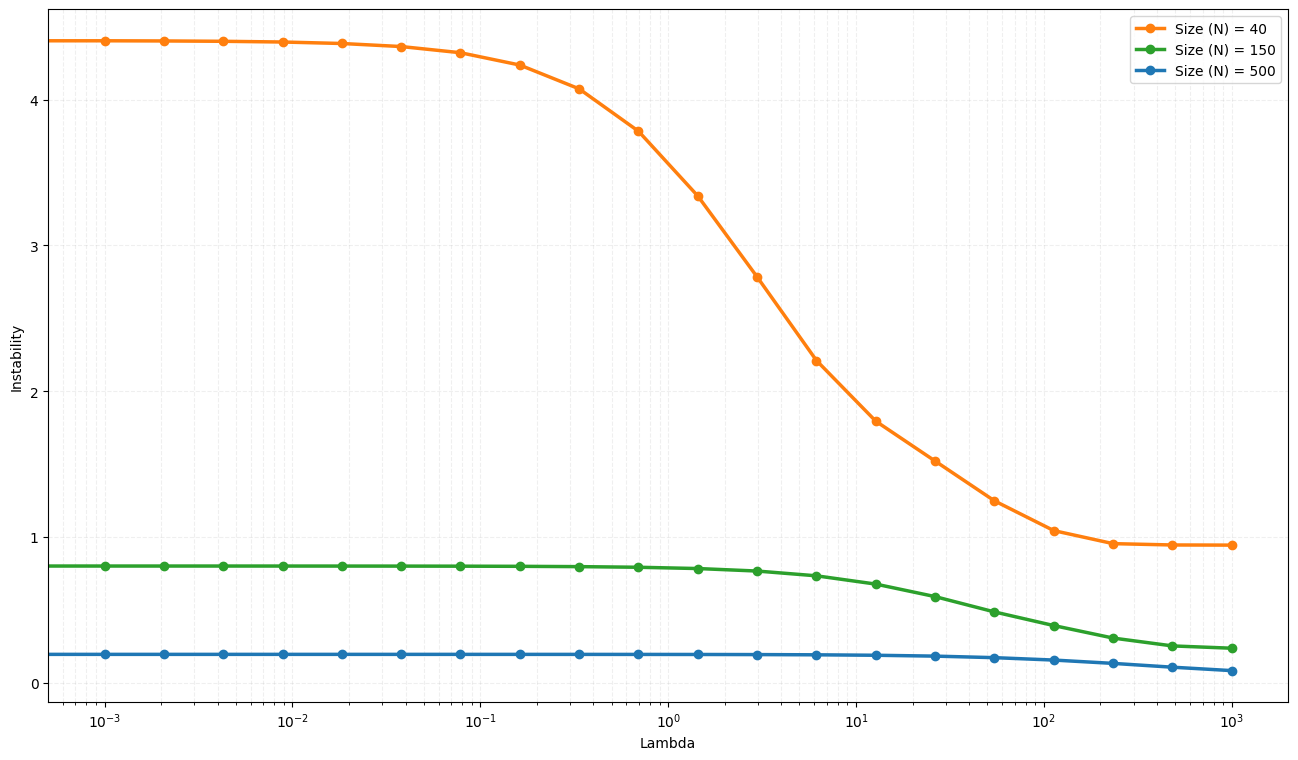

In [29]:
df_size = pd.read_csv('results/results_dataset_size.csv')
sizes = df_size['N'].unique()

plt.figure(figsize=(16, 9))
colors = ['tab:orange', 'tab:green', 'tab:blue']

for i, N in enumerate(sizes):
    df_subset = df_size[df_size['N'] == N]
    plt.plot(df_subset['lambda'], df_subset['instability'], 
             marker='o', linewidth=2.5, label=f'Size (N) = {int(N)}', color=colors[i])

plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Instability')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()

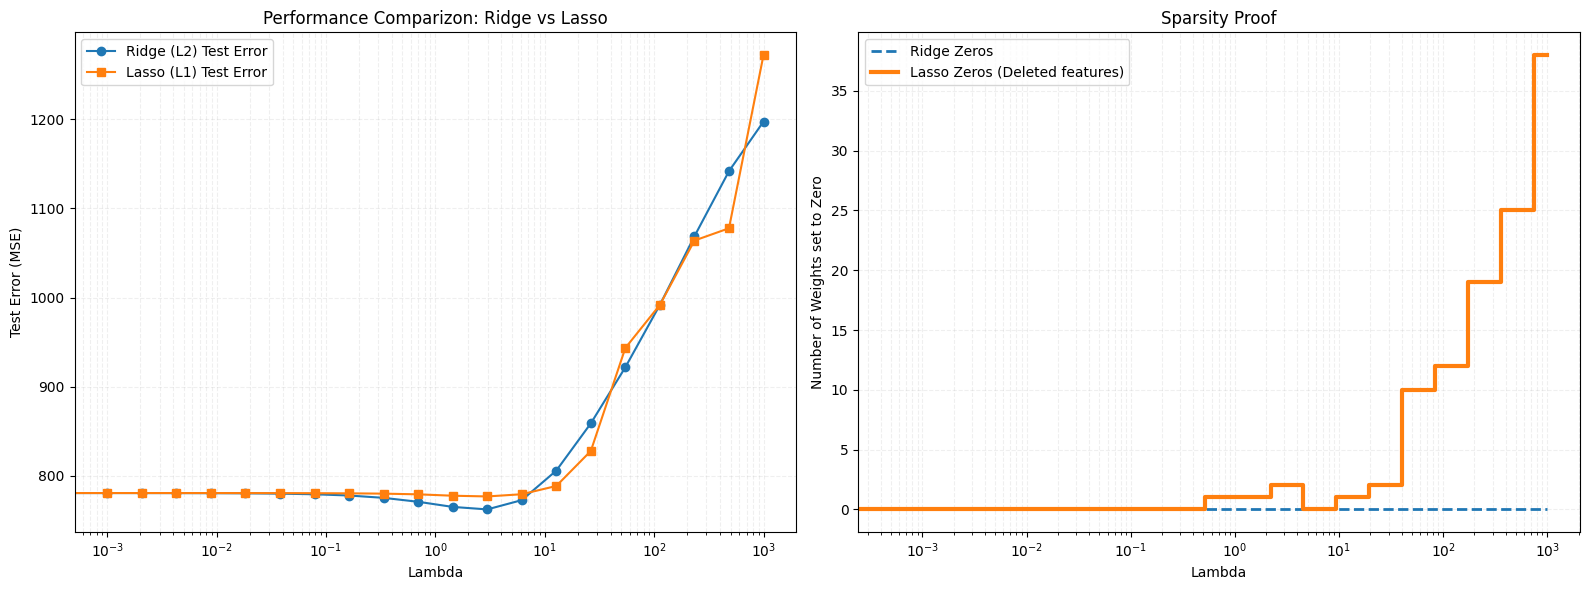

In [ ]:
df_l1l2 = pd.read_csv('results/results_l1_vs_l2.csv')

fig, (ax_err, ax_zeros) = plt.subplots(1, 2, figsize=(16, 6))

ax_err.grid(True, which="both", ls="--", alpha=0.2)
ax_zeros.grid(True, which="both", ls="--", alpha=0.2)

ax_err.set_xscale('log')
ax_err.plot(df_l1l2['lambda'], df_l1l2['ridge_test_error'], marker='o', label='Ridge (L2) Test Error')
ax_err.plot(df_l1l2['lambda'], df_l1l2['lasso_test_error'], marker='s', label='Lasso (L1) Test Error')
ax_err.set_xlabel('Lambda')
ax_err.set_ylabel('Test Error (MSE)')
ax_err.set_title('Performance Comparison: Ridge vs Lasso')
ax_err.legend()


ax_zeros.set_xscale('log')
ax_zeros.plot(df_l1l2['lambda'], df_l1l2['ridge_zeros'], linestyle='--', color='tab:blue', label='Ridge Zeros', linewidth=2)
ax_zeros.step(df_l1l2['lambda'], df_l1l2['lasso_zeros'], where='mid', color='tab:orange', label='Lasso Zeros (Deleted features)', linewidth=3)

ax_zeros.set_xlabel('Lambda')
ax_zeros.set_ylabel('Number of Weights set to Zero')
ax_zeros.set_title('Sparsity Proof')
ax_zeros.legend()


plt.tight_layout()
plt.show()